In [149]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [150]:
pd.__version__, np.__version__


('2.2.3', '2.2.6')

In [151]:
train_path = Path.cwd() / "data/train.csv"
test_path = Path.cwd() / "data/test.csv"
submission_path = Path.cwd() / "data/submission.csv"

#checking if train_path exists 

if train_path.exists():
    print("Exists!")


Exists!


In [152]:
train_csv = pd.read_csv(train_path)
test_csv = pd.read_csv(test_path)
train_csv.head()

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,1
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,1


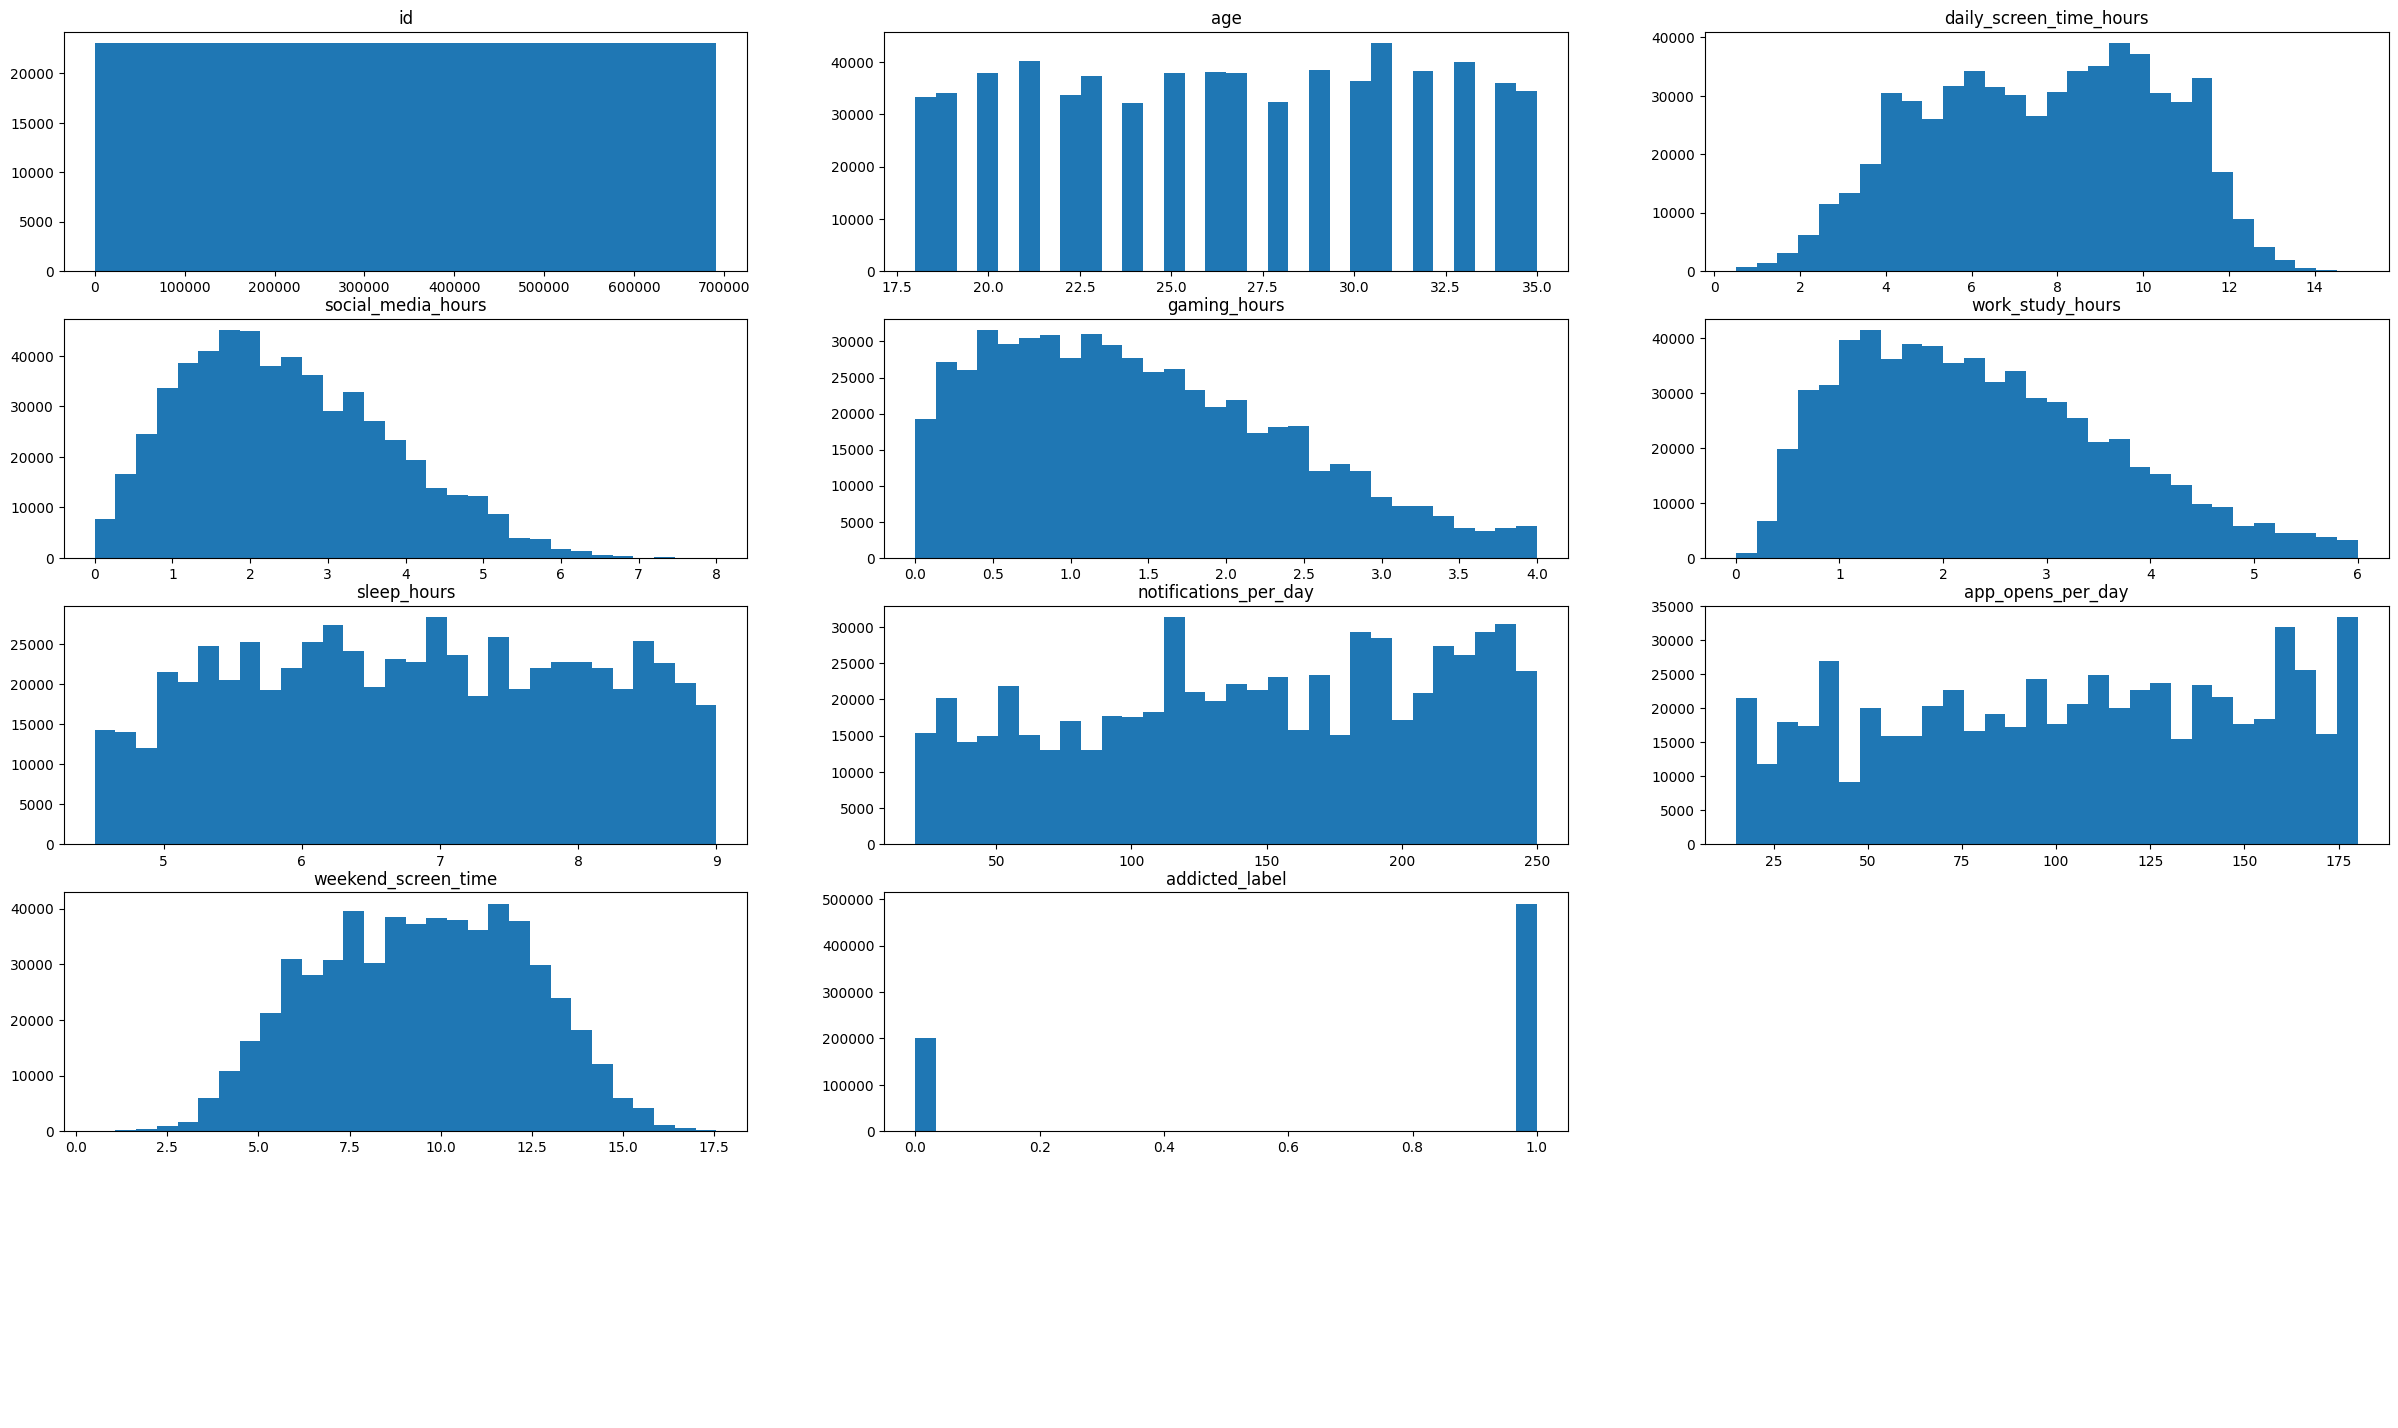

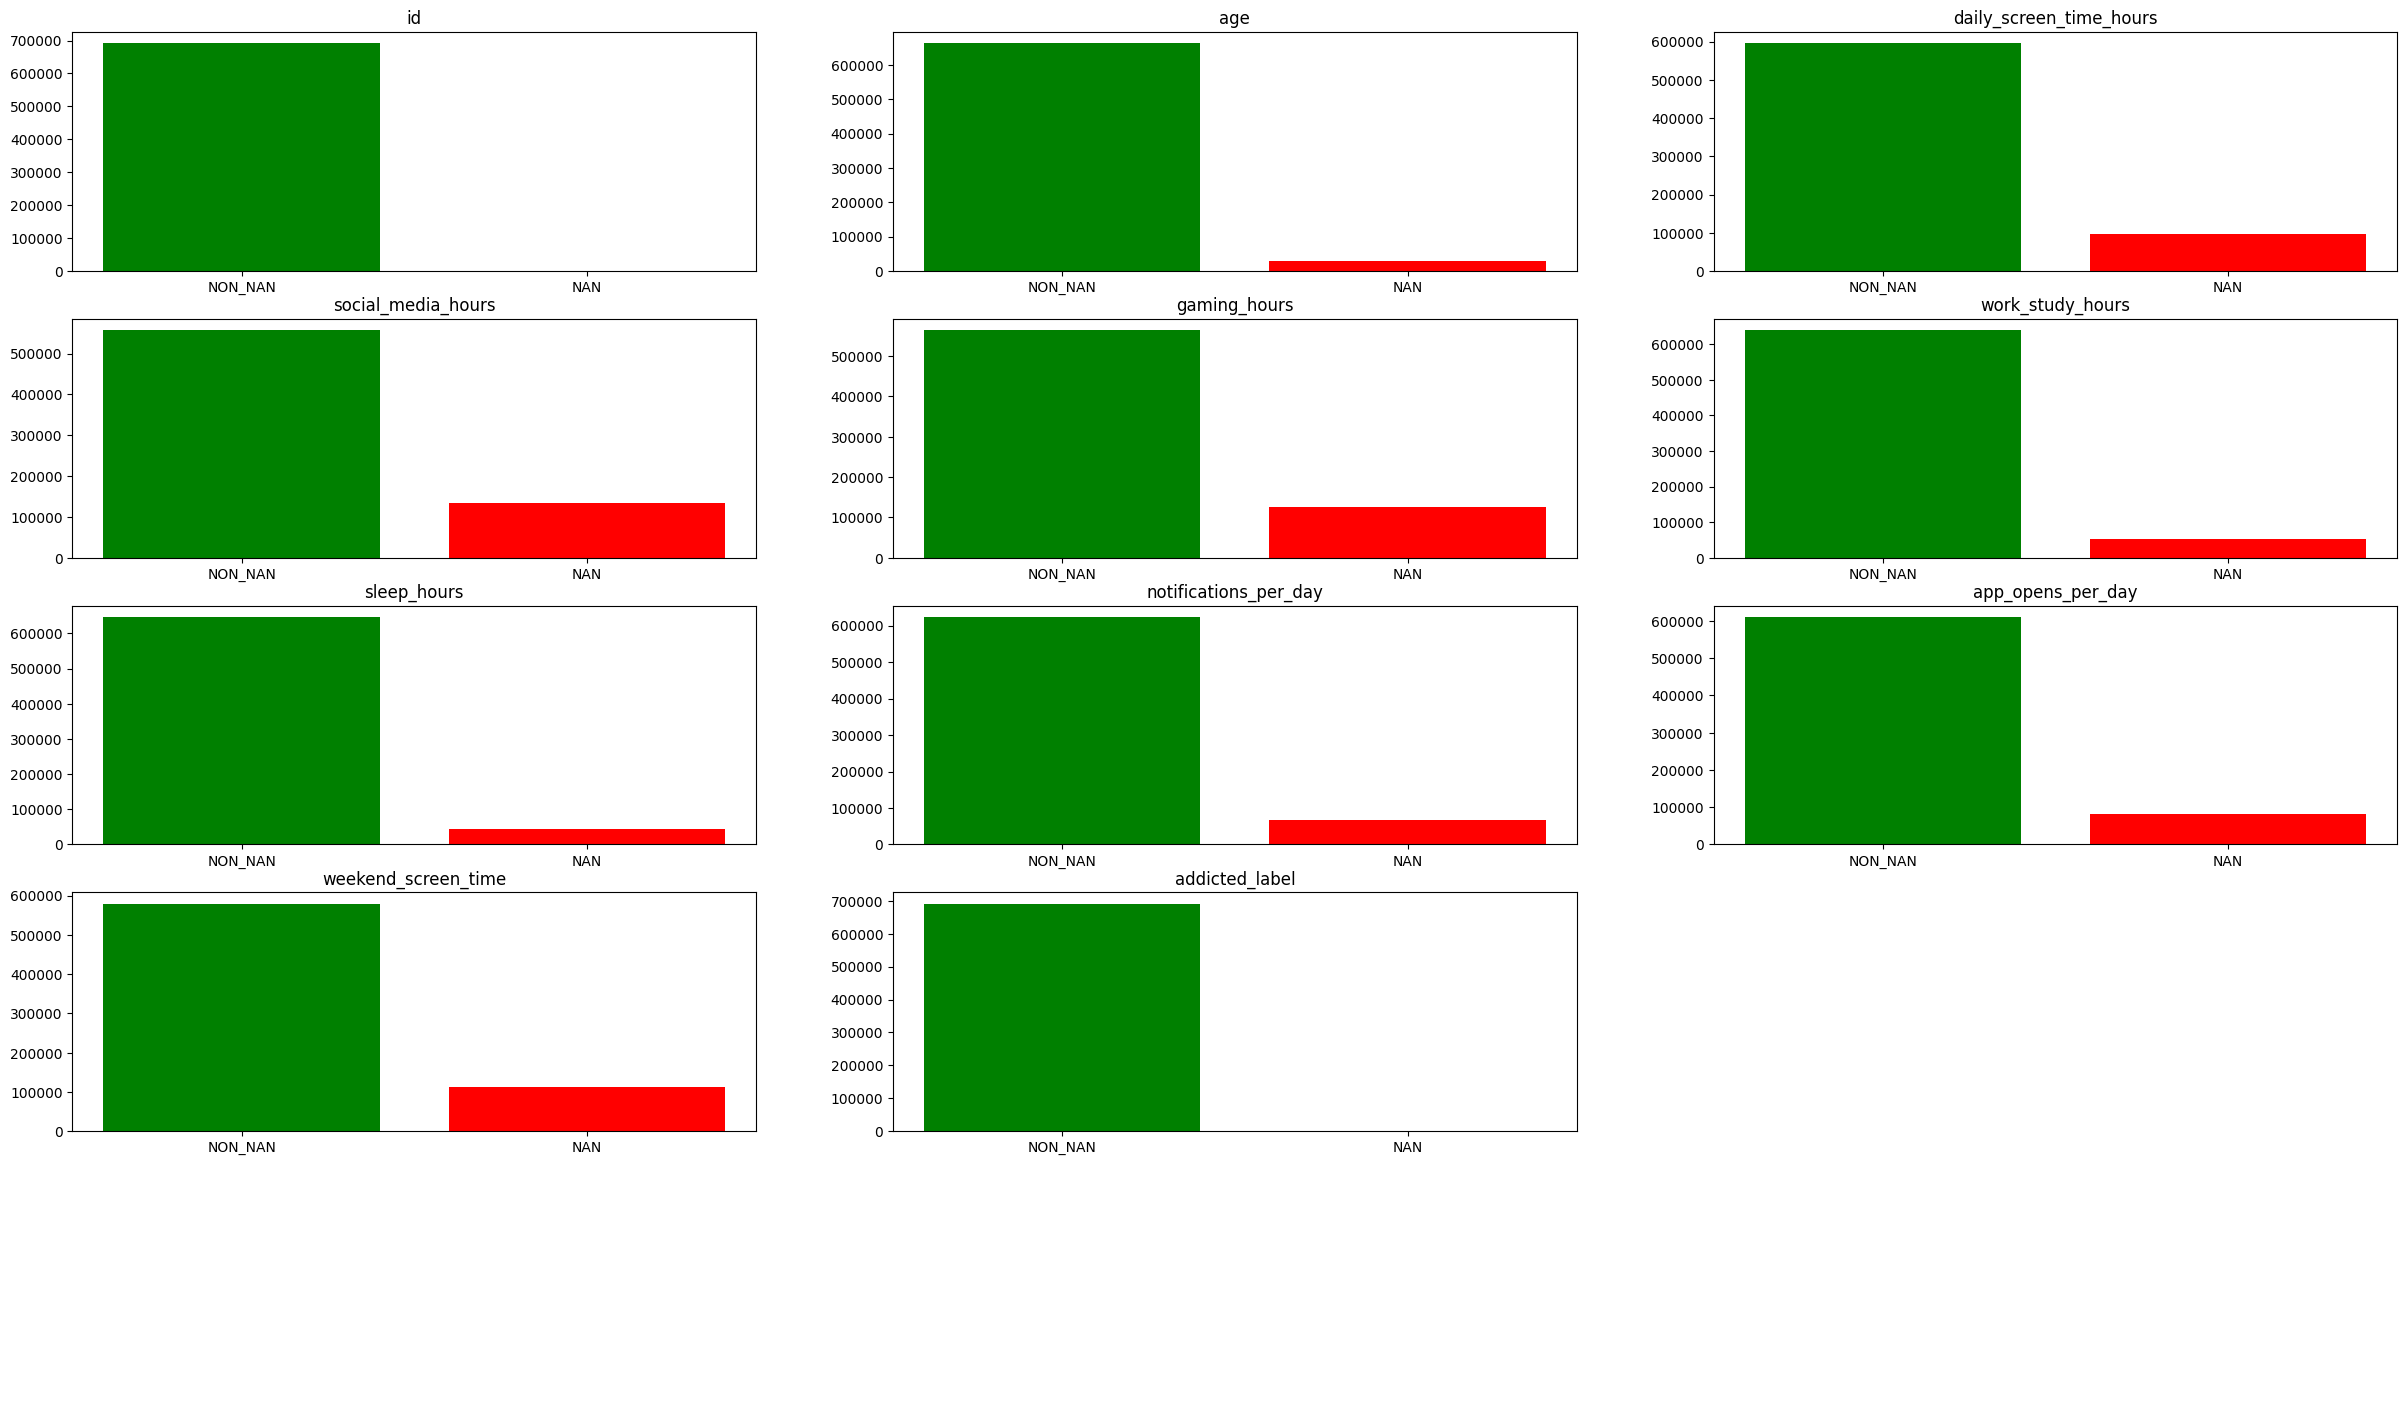

In [153]:
import math
n = len(train_csv.columns)
ncols = 3
nrows = math.ceil(n/ncols)
fig1, axes1 = plt.subplots(nrows=nrows , ncols=ncols, figsize=(nrows*6, ncols*6))
axes1 = axes1.flatten()

fig2, axes2 = plt.subplots(nrows=nrows, ncols=ncols, figsize = (nrows*6, ncols*6) )
axes2 = axes2.flatten()

num_train = train_csv.select_dtypes(exclude="object")

row_num = len(train_csv.index)

for i, col in enumerate(num_train.columns):
    axes1[i].hist(num_train[col], bins=30)
    axes1[i].set_title(f"{col}")
    nans = num_train[col].isna().sum()
    non_nans = num_train[col].notna().sum()
    axes2[i].bar(["NON_NAN", "NAN"], [non_nans, nans], color=["green", "red"])
    axes2[i].set_title(f"{col}")
    
for j in range(i+1, len(axes1)):
    axes1[j].axis("off")
    axes2[j].axis("off")


## INFO BASED ON THOSE GRAPHS

* id needs to be dropped, useless and can damage the model
* age basically sits around 19-35, few nan values can be solved via min-max standardization or no touch for xgboost and other tree-based models
* hours columns are basically all right on graph 1, but still in trouble on graph 2 with so many nan values.
* notification and open app count are more likely a synthetic vals
* addiction is imbalanced 500k vs 200k


In [154]:


for col in train_csv.select_dtypes(exclude="object").columns:
    if train_csv[col].isna().any():
        train_csv[f"is_missing_{col}"] =train_csv[col].isna().astype(int)
train_csv.head()


#recommended sleep is 8 hours, so we need to make a deviation from recommended sleep

train_csv["deviation_from_rec_sleep"] = np.abs(train_csv["sleep_hours"] - 8)


conditions = [
    (train_csv["sleep_hours"] >= 7) & (train_csv["sleep_hours"] <= 9),
    train_csv["sleep_hours"] > 9,
    train_csv["sleep_hours"] < 7
]

choices = [
    "Normal", "Long", "Short"
]

train_csv["sleep_category"] = np.select(conditions, choices, default="Unknown")


train_csv.head()

                           


,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,...,is_missing_daily_screen_time_hours,is_missing_social_media_hours,is_missing_gaming_hours,is_missing_work_study_hours,is_missing_sleep_hours,is_missing_notifications_per_day,is_missing_app_opens_per_day,is_missing_weekend_screen_time,deviation_from_rec_sleep,sleep_category
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,...,1,0,0,0,0,0,0,0,0.54,Normal
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,...,0,0,1,0,0,0,0,1,0.22,Normal
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,...,0,1,1,1,0,0,0,0,1.75,Short
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,...,0,0,0,0,0,0,0,0,0.85,Normal
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,...,0,0,0,0,0,1,1,0,2.75,Short


In [ ]:
from sklearn.model_selection import StratifiedKFold
import xgboost as xgb
import lightgbm as lgb
import catboost as ctb
from sklearn.metrics import classification_report
from sklearn.utils.class_weight import compute_sample_weight

model = xgb.XGBClassifier(
    n_estimators=5000,
    learning_rate=0.01,
    enable_categorical=True,
    tree_method="hist",
    eta=0.01,
    max_depth=8,
    subsample=0.5,
    colsample_bytree=0.5
)
sk = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

train_df = train_csv.drop("id", axis=1)

X, y = train_df.drop('addicted_label', axis=1), train_df['addicted_label']

for col in X.select_dtypes(include="object"):
    X[col] = X[col].astype("category")

for fold, (train_idx, val_idx) in enumerate(sk.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)


    model.fit(X_train, y_train, sample_weight=sample_weights)

    y_preds = model.predict(X_val) 
    
    print(classification_report(y_val, y_preds))





              precision    recall  f1-score   support

           0       0.76      0.91      0.83     40179
           1       0.96      0.88      0.92     98095

    accuracy                           0.89    138274
   macro avg       0.86      0.89      0.87    138274
weighted avg       0.90      0.89      0.89    138274

              precision    recall  f1-score   support

           0       0.76      0.91      0.83     40179
           1       0.96      0.88      0.92     98095

    accuracy                           0.89    138274
   macro avg       0.86      0.90      0.87    138274
weighted avg       0.90      0.89      0.89    138274

              precision    recall  f1-score   support

           0       0.76      0.91      0.83     40179
           1       0.96      0.88      0.92     98095

    accuracy                           0.89    138274
   macro avg       0.86      0.90      0.87    138274
weighted avg       0.90      0.89      0.89    138274

